<a href="https://colab.research.google.com/github/Prathameshshelke145/pcb_defect_detection/blob/main/PR_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Delete Folder

In [ ]:
import shutil

shutil.rmtree("/content/extracted_pcb_dataset_new")
shutil.rmtree("/content/extracted_pcb_dataset_new_new")

#data Preparing

In [ ]:

import numpy as np
import pandas as pd

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:

import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/extracted_pcb_dataset/augmented.zip" -d "/content/extracted_pcb_dataset_new_new"

Archive:  /content/drive/MyDrive/extracted_pcb_dataset/augmented.zip
   creating: /content/extracted_pcb_dataset_new_new/augmented/
   creating: /content/extracted_pcb_dataset_new_new/augmented/Corrected_BR/
  inflating: /content/extracted_pcb_dataset_new_new/augmented/Corrected_BR/Corrected_BR_aug_100.jpg  
  inflating: /content/extracted_pcb_dataset_new_new/augmented/Corrected_BR/Corrected_BR_aug_101.jpg  
  inflating: /content/extracted_pcb_dataset_new_new/augmented/Corrected_BR/Corrected_BR_aug_102.jpg  
  inflating: /content/extracted_pcb_dataset_new_new/augmented/Corrected_BR/Corrected_BR_aug_105.jpg  
  inflating: /content/extracted_pcb_dataset_new_new/augmented/Corrected_BR/Corrected_BR_aug_106.jpg  
  inflating: /content/extracted_pcb_dataset_new_new/augmented/Corrected_BR/Corrected_BR_aug_107.jpg  
  inflating: /content/extracted_pcb_dataset_new_new/augmented/Corrected_BR/Corrected_BR_aug_108.jpg  
  inflating: /content/extracted_pcb_dataset_new_new/augmented/Corrected_BR/Cor

#Preprocessing pipline

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory

In [ ]:
!pip install keras_cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 36.9 MB/s eta 0:00:00


In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory
import keras_cv
from keras.layers import RandomFlip, RandomRotation, RandomZoom, GaussianNoise
from keras_cv.layers import (
    RandomShear,
    RandomSharpness,
    RandomGaussianBlur,
    RandomBrightness,
    RandomContrast,
    Resizing
)
from keras.models import Sequential

pipe = Sequential([

    RandomFlip(mode=np.random.choice(["horizontal","vertical"])),
    # RandomRotation(factor=(-0.2, 0.2),
    #                fill_mode="constant",
    #                interpolation="nearest"),
    # GaussianNoise(stddev=0.1),
    # RandomShear(x_factor=(0.2),
    #             y_factor=(0.2),
    #             fill_mode="constant",
    #             interpolation="nearest"),
    RandomSharpness(factor=(0.0, 0.5),
                    value_range=(0,255)),
    # RandomGaussianBlur(kernel_size=3,
    #                    factor=(0.0, 0.1)),
    RandomBrightness(value_range=(0, 255),
                     factor=(-0.2, 0.2)),
    Resizing(256, 256)

])

In [ ]:

img_height = 256
img_width = 256
batch_size = 32

data_path ="/content/extracted_pcb_dataset_new_new/augmented"
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=data_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    directory=data_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)


Found 4029 files belonging to 10 classes.
Using 3224 files for training.
Found 4029 files belonging to 10 classes.
Using 805 files for validation.


In [ ]:
class_names = train_ds.class_names

In [ ]:
len(class_names)

10

In [ ]:
train_ds = train_ds.map(lambda x, y: (pipe(x, training=True), y))


In [ ]:
val_ds = val_ds.map(lambda x, y: (pipe(x, training=True), y))

In [ ]:
train_ds

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
path="/content/extracted_pcb_dataset_new_new/augmented/missing_R7/Screenshot 2025-10-04 121623.png"

In [ ]:
from tensorflow.keras.utils import load_img,img_to_array
img=load_img(path)
img=img_to_array(img)
img1=img/255




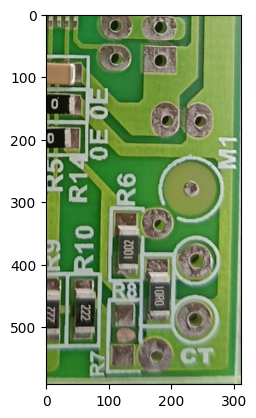

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(img1)

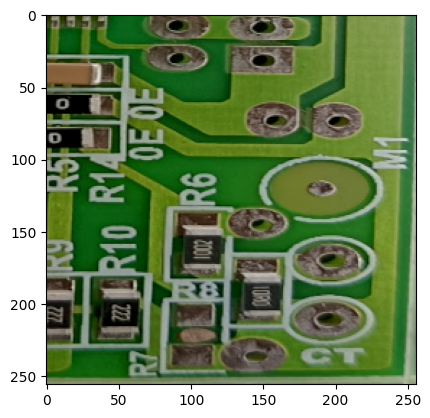

In [ ]:
import tensorflow as tf

img2=pipe(tf.expand_dims(img, axis=0))
img2=tf.squeeze(img2,axis=0)
img2=img2/255

plt.imshow(img2)

#model Architecture

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras import models

In [ ]:
num_classes = 10
img_height = 256
img_width = 256

model = models.Sequential()


model.add(layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)))

model.add(layers.Conv2D(32, (3,3), activation='relu', padding="same"))
model.add(layers.Conv2D(32, (3,3), activation='relu', padding="same"))
model.add(layers.MaxPooling2D((2,2)))


model.add(layers.Conv2D(64, (3,3), activation='relu', padding="same"))
model.add(layers.Conv2D(64, (3,3), activation='relu', padding="same"))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.BatchNormalization())


model.add(layers.Conv2D(128, (3,3), activation='relu', padding="same"))
model.add(layers.Conv2D(128, (3,3), activation='relu', padding="same"))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.BatchNormalization())


model.add(layers.Conv2D(256, (3,3), activation='relu', padding="same"))
model.add(layers.Conv2D(256, (3,3), activation='relu', padding="same"))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.BatchNormalization())

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(num_classes, activation='softmax'))   # probability output

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,985,706 (68.61 MB)

 Trainable params: 17,984,810 (68.61 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    ]
)


Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 130s 982ms/step - accuracy: 0.4129 - loss: 2.1920 - val_accuracy: 0.0994 - val_loss: 3.1686
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 80s 786ms/step - accuracy: 0.8024 - loss: 0.5824 - val_accuracy: 0.0994 - val_loss: 4.9577
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 71s 682ms/step - accuracy: 0.9074 - loss: 0.2676 - val_accuracy: 0.0994 - val_loss: 5.7759
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 68s 672ms/step - accuracy: 0.9203 - loss: 0.2702 - val_accuracy: 0.0994 - val_loss: 9.4429
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 69s 681ms/step - accuracy: 0.9462 - loss: 0.1741 - val_accuracy: 0.4410 - val_loss: 2.1962
Epoch 6/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 69s 683ms/step - accuracy: 0.9640 - loss: 0.1206 - val_accuracy: 0.7876 - val_loss: 0.7894
Epoch 7/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 68s 671ms/step - accuracy: 0.9626 - loss: 0.1185 - val_accuracy: 0.9752 - val_loss: 0.0732
Epoch 8/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 83s 683ms/step - accuracy: 0.9725 - loss: 

In [ ]:
model.save("model_Final_pcb3.keras")

In [ ]:
# Epoch 1/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.2234 - loss: 2.6540 - val_accuracy: 0.1519 - val_loss: 2.1247
# Epoch 2/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.4842 - loss: 1.4197 - val_accuracy: 0.2091 - val_loss: 3.1528
# Epoch 3/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.5965 - loss: 1.1090 - val_accuracy: 0.1247 - val_loss: 4.2138
# Epoch 4/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.6636 - loss: 0.9088 - val_accuracy: 0.1792 - val_loss: 4.7607
# Epoch 5/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.7178 - loss: 0.7849 - val_accuracy: 0.4338 - val_loss: 2.4514
# Epoch 6/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.7550 - loss: 0.6886 - val_accuracy: 0.5896 - val_loss: 2.1442
# Epoch 7/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.7931 - loss: 0.5893 - val_accuracy: 0.7701 - val_loss: 0.8296
# Epoch 8/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8174 - loss: 0.4969 - val_accuracy: 0.8156 - val_loss: 0.5927
# Epoch 9/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.8583 - loss: 0.4195 - val_accuracy: 0.9091 - val_loss: 0.2704
# Epoch 10/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8717 - loss: 0.3748 - val_accuracy: 0.9234 - val_loss: 0.2431
# Epoch 11/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8836 - loss: 0.3538 - val_accuracy: 0.8636 - val_loss: 0.4551
# Epoch 12/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8995 - loss: 0.3234 - val_accuracy: 0.8532 - val_loss: 0.6525
# Epoch 13/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9057 - loss: 0.2663 - val_accuracy: 0.9247 - val_loss: 0.2632
# Epoch 14/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.9313 - loss: 0.2083 - val_accuracy: 0.9364 - val_loss: 0.1985
# Epoch 15/20
# 97/97 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9209 - loss: 0.2250 - val_accuracy: 0.9442 - val_loss: 0.1952
# Epoch 16/20
# 27/97 ━━━━━━━━━━━━━━━━━━━━ 1:18 1s/step - accuracy: 0.9338 - loss: 0.1996

26/26 - 12s - 462ms/step - accuracy: 0.9863 - loss: 0.0451


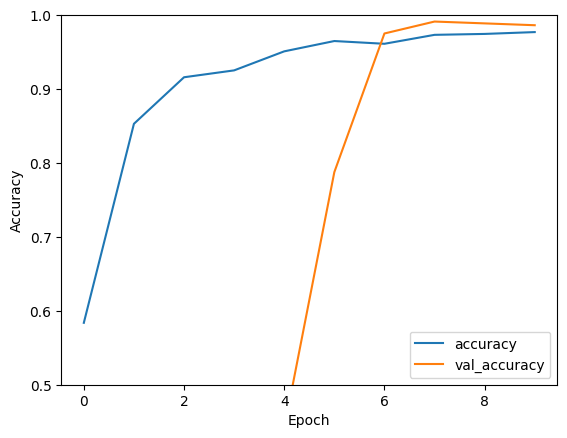

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(val_ds, verbose=2)

#Transfer learning

In [ ]:
from tensorflow.keras import layers
num_classes = 7
img_height = 256
img_width = 256

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(img_height, img_width, 3)
)
base_model.trainable = False


model2 = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

In [ ]:
# Step 1: Train only top layers
base_model.trainable = False
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history = model2.fit(train_ds, validation_data=val_ds, epochs=10)




base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history_finetune = model2.fit(train_ds, validation_data=val_ds, epochs=10)


Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.1311 - loss: 1.9689 - val_accuracy: 0.1312 - val_loss: 1.9555
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.1324 - loss: 1.9733 - val_accuracy: 0.1312 - val_loss: 1.9516
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.1245 - loss: 1.9589 - val_accuracy: 0.1312 - val_loss: 1.9476
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.1398 - loss: 1.9538 - val_accuracy: 0.1519 - val_loss: 1.9462
Epoch 5/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.1346 - loss: 1.9522 - val_accuracy: 0.1532 - val_loss: 1.9465
Epoch 6/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.1509 - loss: 1.9494 - val_accuracy: 0.1312 - val_loss: 1.9473
Epoch 7/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.1248 - loss: 1.9509 - val_accuracy: 0.1312 - val_loss: 1.9473
Epoch 8/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.1372 - loss: 1.9479 - val_accuracy: 0.1403 - v

In [ ]:
save(/content/extracted_pcb_dataset_new_new/final_folder)

'' was not found in history, as a file, url, nor in the user namespace.


#input_data

In [ ]:
import cv2

# Read the image
image = cv2.imread("/content/process.png")

# Get height and width
h, w, _ = image.shape

# Split points
vertical_split = w // 2
horizontal_split = h // 2

# Four quadrants
top_left = image[0:horizontal_split, 0:vertical_split]
top_right = image[0:horizontal_split, vertical_split:w]
bottom_left = image[horizontal_split:h, 0:vertical_split]
bottom_right = image[horizontal_split:h, vertical_split:w]

# --- Full-width center crop ---
center_height = horizontal_split//4  # You can adjust this thickness
cy = int(0.8*horizontal_split)  # center y-coordinate
center = image[cy - center_height//2 : cy + center_height, 0:w]  # full width

# Save all
cv2.imwrite("pcb_top_left.jpg", top_left)
cv2.imwrite("pcb_top_right.jpg", top_right)
cv2.imwrite("pcb_bottom_left.jpg", bottom_left)
cv2.imwrite("pcb_bottom_right.jpg", bottom_right)
cv2.imwrite("pcb_center.jpg", center)

print("✅ Cropping done. 5 images saved (center is full width).")


✅ Cropping done. 5 images saved (center is full width).


#Testing

In [ ]:
class_names=['Corrected_BR',
 'Corrected_IC2',
 'Corrected_R7',
 'Corrected_iC1',
 'defected_BR!',
 'miss_align_ic1',
 'miss_aligned_ic2',
 'missing_R7',
 'shifted_R7',
 'white_R7']

In [ ]:
ok="/content/shifted_defect.png/"

In [ ]:
model = keras.models.load_model("/content/model_Final_pcb3.keras")


In [ ]:
input_lidt=[
            "/content/pcb_bottom_right.jpg",
            "/content/pcb_bottom_left.jpg",
            "/content/pcb_center.jpg",
            "/content/pcb_top_left.jpg",
            "/content/pcb_top_right.jpg"
            ]

In [ ]:
import tensorflow as tf
for i in input_lidt:
    img_path = i
    img = tf.keras.utils.load_img(img_path)
    img = tf.keras.utils.img_to_array(img)
    img = tf.expand_dims(img, 0)

    img_processed = pipe(img, training=False)
    pred = model.predict(img_processed)
    prob = tf.nn.softmax(pred[0])
    class_id = tf.argmax(prob).numpy()
    confidence = tf.reduce_max(prob).numpy()

    print("------------------------------------------------------------------------------")
    print(i)
    print("deatected class : ",class_names[class_id])
    print("confidence : ",confidence)
    print("------------------------------------------------------------------------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
------------------------------------------------------------------------------
/content/pcb_bottom_right.jpg
deatected class :  shifted_R7
confidence :  0.23196742
------------------------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
------------------------------------------------------------------------------
/content/pcb_bottom_left.jpg
deatected class :  Corrected_iC1
confidence :  0.12383525
------------------------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
------------------------------------------------------------------------------
/content/pcb_center.jpg
deatected class :  Corrected_IC2
confidence :  0.23188096
------------------------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
------------------------------------------------------------------------------
/content/pcb_top_left.jpg
deatected class